In [1]:
#Cell 1: Import Libraries:

# ============================================================
# ☄️ ASTEROID HAZARD CLASSIFIER — NASA Near Earth Objects
# Built by: Kartik | Munich | 2025
# Goal: Predict which asteroids are dangerous to Earth
# ============================================================

#Core libraries
import numpy as np 
import pandas as pd 

#Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns 

#Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score)

#Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

print("✅ All libraries imported successfully!")
print("☄️ Asteroid Hazard Classifier is ready!")


✅ All libraries imported successfully!
☄️ Asteroid Hazard Classifier is ready!


In [2]:
# ============================================================
# CELL 2: Load the NASA Asteroid Dataset
# ============================================================

#Load the data
df = pd.read_csv('neo_v2.csv')

#First look
print("☄️  NASA NEAR EARTH OBJECTS DATASET")
print("=" * 50)
print(f"📊 Total asteroids:  {df.shape[0]}")
print(f"📋 Total features:   {df.shape[1]}")
print("=" * 50)

#Column names
print("\n COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

#First 5 rows:
print("\n First 5 rows:")
print(df.head())

#Check target column
print("\n HAZARDOUS COLUMN:")
print(df['hazardous'].value_counts())


☄️  NASA NEAR EARTH OBJECTS DATASET
📊 Total asteroids:  90836
📋 Total features:   10

 COLUMNS:
   1. id
   2. name
   3. est_diameter_min
   4. est_diameter_max
   5. relative_velocity
   6. miss_distance
   7. orbiting_body
   8. sentry_object
   9. absolute_magnitude
  10. hazardous

 First 5 rows:
        id                 name  est_diameter_min  est_diameter_max  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.265800          0.594347   
2  2512244   512244 (2015 YE18)          0.722030          1.614507   
3  3596030          (2012 BV13)          0.096506          0.215794   
4  3667127          (2014 GE35)          0.255009          0.570217   

   relative_velocity  miss_distance orbiting_body  sentry_object  \
0       13569.249224   5.483974e+07         Earth          False   
1       73588.726663   6.143813e+07         Earth          False   
2      114258.692129   4.979872e+07         Earth          False  

 ASTEROID DATA EXPLORATION

🌍 HAZARD BREAKDOWN:
   Total Asteroids:     90,836
   ☄️  Hazardous:        8,840 (9.7%)
   ✅ Not Hazardous:    81,996 (90.3%)


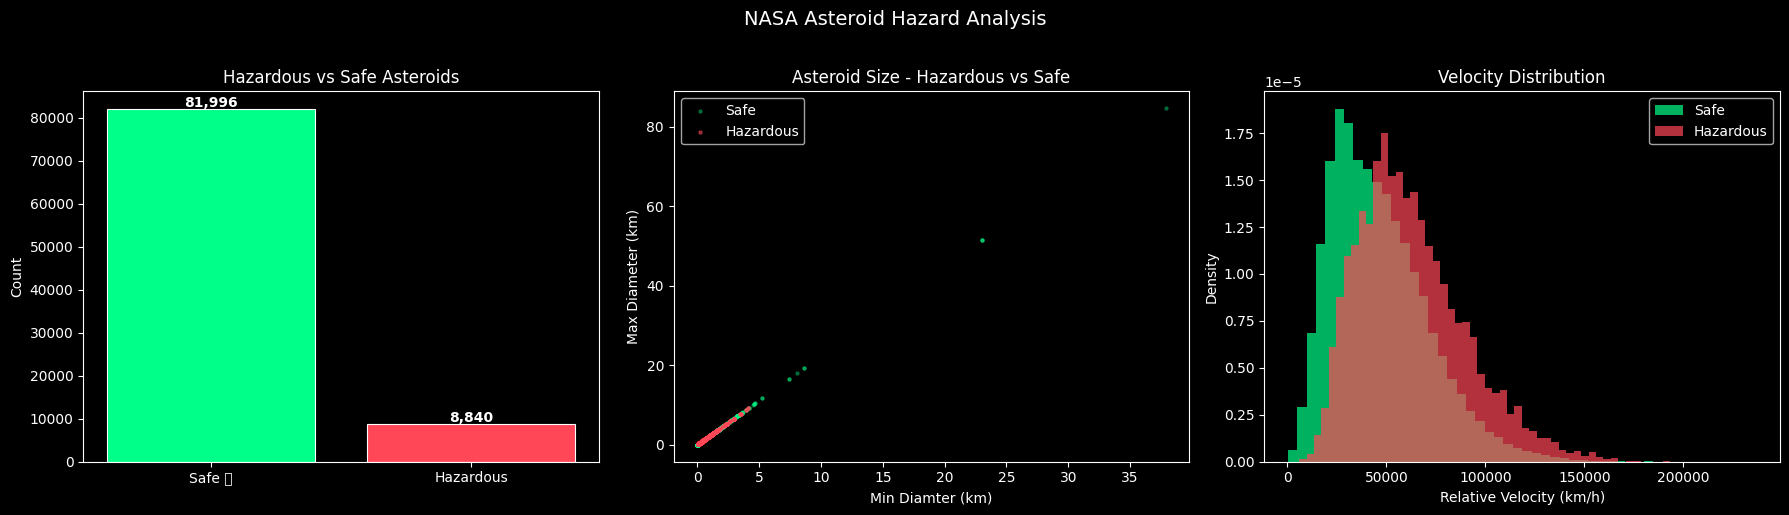


 KEY MEASUREMENTS: 

   est_diameter_min
   Safe Mean:    0.1095
   Hazardous Mean:  0.2941

   est_diameter_max
   Safe Mean:    0.2448
   Hazardous Mean:  0.6577

   relative_velocity
   Safe Mean:    46479.1540
   Hazardous Mean:  62794.3370

   miss_distance
   Safe Mean:    36756086.8845
   Hazardous Mean:  39946230.2082


In [4]:
# ============================================================
# CELL 3: Explore the Data
# ============================================================

print(" ASTEROID DATA EXPLORATION")
print("="*50)

#Harzardous breadown
total = len(df)
hazardous = df['hazardous'].sum()
safe = total - hazardous

print(f"\n🌍 HAZARD BREAKDOWN:")
print(f"   Total Asteroids:     {total:,}")
print(f"   ☄️  Hazardous:        {hazardous:,} ({hazardous/total*100:.1f}%)")
print(f"   ✅ Not Hazardous:    {safe:,} ({safe/total*100:.1f}%)")

#Visualise hazard distribution:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Plot 1 - Hazard Count
colors = ['#00ff88', '#ff4757']
axes[0].bar(['Safe ✅', 'Hazardous'],
            [safe, hazardous],
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Hazardous vs Safe Asteroids', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate([safe, hazardous]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

#Plot 2 - Diameter vs Hazard
axes[1].scatter(
    df[df['hazardous']==False]['est_diameter_min'],
    df[df['hazardous']==False]['est_diameter_max'],
    alpha=0.3, color='#00ff88', label='Safe', s=5
)
axes[1].scatter(
    df[df['hazardous']==True]['est_diameter_min'],
    df[df['hazardous']==True]['est_diameter_max'],
    alpha=0.5, color='#ff4757', label='Hazardous', s=5
)
axes[1].set_title('Asteroid Size - Hazardous vs Safe', fontsize=12)
axes[1].set_xlabel('Min Diamter (km)')
axes[1].set_ylabel('Max Diameter (km)')
axes[1].legend()


#Plot 3 - Velocity vs Hazard
axes[2].hist(df[df['hazardous']==False]['relative_velocity'],
             bins=50, alpha=0.7, color='#00ff88',
             label='Safe', density=True)
axes[2].hist(df[df['hazardous']==True]['relative_velocity'],
             bins=50, alpha=0.7, color='#ff4757',
             label='Hazardous', density=True)
axes[2].set_title('Velocity Distribution', fontsize=12)
axes[2].set_xlabel('Relative Velocity (km/h)')
axes[2].set_ylabel('Density')
axes[2].legend() 

plt.suptitle('NASA Asteroid Hazard Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#Key statistics
print("\n KEY MEASUREMENTS: ")
print("="*50)
for col in ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitute']:
    if col in df.columns:
        print(f"\n   {col}")
        print(f"   Safe Mean:    {df[df['hazardous']==False][col].mean():.4f}")
        print(f"   Hazardous Mean:  {df[df['hazardous']==True][col].mean():.4f}")



In [5]:
# ============================================================
# CELL 4: Prepare Data for ML
# ============================================================

print("PREPARING DATA FOR ML...")
print("="*50)

#Check column names
print("\n All columns:")
print(df.columns.tolist())

#Drop non-useful columns
cols_to_drop = ['id', 'name', 'orbiting_body', 'sentry_object']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

print(f"\n Dropped ID/text columns")
print(f" Remaining columns:  {df_clean.columns.tolist()}")

#Separate features and target:
X = df_clean.drop('hazardous', axis=1)
y = df_clean['hazardous'].astype(int) #True=1, False=0

print(f"\n Features (X): {X.shape}") 
print(f" Target (y): {y.shape}") 
print(f"\n Hazardous (1):  {y.sum():,}")
print(f"   Safe     (0):  {(y==0).sum():,}")

#Check missing values
print(f"\n Missing values:  {X.isnull().sum().sum()}")

#Keep numeric only
X = X.select_dtypes(include=[np.number])
print(f" Numberic features: {X.shape[1]}")

#Train/Test Split - stratify because imbalanced!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n TRAIN/TEST SPLIT :")
print(f"  Training: {X_train.shape[0]:,} asteroids")
print(f"  Testing:  {X_test.shape[0]:,} asteroids")

#Check hazard ratio preserved
print(f"\n Hazardous in train:  {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  Hazardous in test:  {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Features scaled!")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"   Std:  {X_train_scaled.std():.6f}")
print("\n Data ready - let's hunt some asteroids!") 

PREPARING DATA FOR ML...

 All columns:
['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']

 Dropped ID/text columns
 Remaining columns:  ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']

 Features (X): (90836, 5)
 Target (y): (90836,)

 Hazardous (1):  8,840
   Safe     (0):  81,996

 Missing values:  0
 Numberic features: 5

 TRAIN/TEST SPLIT :
  Training: 72,668 asteroids
  Testing:  18,168 asteroids

 Hazardous in train:  7,072 (9.7%)
  Hazardous in test:  1,768  (9.7%)

 Features scaled!
  Mean: -0.000000
   Std:  1.000000

 Data ready - let's hunt some asteroids!


In [8]:
# ============================================================
# CELL 5: Train Models — Imbalance Fixed Properly
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight='balanced'),
    'KNN': KNeighborsClassifier(
        n_neighbors=3),    # smaller K helps minority class
}

results = {}

print("🚀 TRAINING ASTEROID HAZARD MODELS...")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred    = model.predict(X_test_scaled)
    acc       = accuracy_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test,
                model.predict_proba(X_test_scaled)[:,1])

    results[name] = {
        'acc': acc, 'recall': recall,
        'precision': precision,
        'f1': f1, 'auc': auc,
        'y_pred': y_pred
    }

    print(f"\n☄️  {name}")
    print(f"   Accuracy:  {acc*100:.2f}%")
    print(f"   Recall:    {recall*100:.2f}%  ← Catching hazardous!")
    print(f"   Precision: {precision*100:.2f}%")
    print(f"   F1 Score:  {f1*100:.2f}%")
    print(f"   AUC:       {auc:.3f}")

print("\n" + "=" * 60)
best = max(results, key=lambda x: results[x]['recall'])
print(f"\n🏆 BEST MODEL: {best}")
print(f"   Recall:    {results[best]['recall']*100:.2f}%")
print(f"   Precision: {results[best]['precision']*100:.2f}%")
print(f"   F1:        {results[best]['f1']*100:.2f}%")
print(f"   AUC:       {results[best]['auc']:.3f}")
print(f"\n💡 WHY RECALL MATTERS:")
print(f"   Missing a hazardous asteroid = potential disaster! 🌍")




### 💡 Key changes:
'''  
Logistic Regression → class_weight='balanced' ✅
Decision Tree       → class_weight='balanced' ✅
KNN                 → n_neighbors=3 (smaller K catches more minority)
''' 

🚀 TRAINING ASTEROID HAZARD MODELS...

☄️  Logistic Regression
   Accuracy:  78.59%
   Recall:    93.21%  ← Catching hazardous!
   Precision: 30.42%
   F1 Score:  45.87%
   AUC:       0.879

☄️  Decision Tree
   Accuracy:  79.43%
   Recall:    97.62%  ← Catching hazardous!
   Precision: 31.83%
   F1 Score:  48.01%
   AUC:       0.904

☄️  KNN
   Accuracy:  89.61%
   Recall:    36.43%  ← Catching hazardous!
   Precision: 45.77%
   F1 Score:  40.57%
   AUC:       0.800


🏆 BEST MODEL: Decision Tree
   Recall:    97.62%
   Precision: 31.83%
   F1:        48.01%
   AUC:       0.904

💡 WHY RECALL MATTERS:
   Missing a hazardous asteroid = potential disaster! 🌍


"  \nLogistic Regression → class_weight='balanced' ✅\nDecision Tree       → class_weight='balanced' ✅\nKNN                 → n_neighbors=3 (smaller K catches more minority)\n"

☄️  CONFUSION MATRIX: Decision Tree

   ✅ True Positives  (caught hazardous):     1,726
   ✅ True Negatives  (correctly safe):        12,704
   ⚠️  False Positives (false alarms):          3,696
   🚨 False Negatives (MISSED hazardous!):     42

💡 REAL WORLD MEANING:
   We caught 1,726 dangerous asteroids ✅
   We missed only 42 dangerous asteroids 🚨
   We raised 3,696 false alarms ⚠️

   Missing rate: 2.38% of hazardous missed
   Catch rate:   97.62% of hazardous caught 🏆


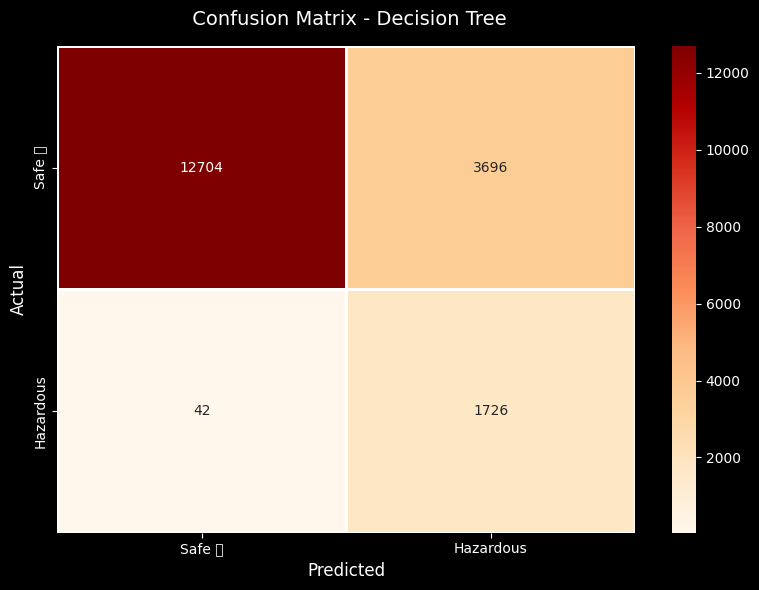


 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Safe       1.00      0.77      0.87     16400
  Hazarrdous       0.32      0.98      0.48      1768

    accuracy                           0.79     18168
   macro avg       0.66      0.88      0.68     18168
weighted avg       0.93      0.79      0.83     18168



In [9]:
# ============================================================
# CELL 6: Confusion Matrix — Asteroid Hazard Deep Dive
# ============================================================

best_model = models[best]
y_pred_best = results[best]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"☄️  CONFUSION MATRIX: {best}")
print("=" * 60)
print(f"\n   ✅ True Positives  (caught hazardous):     {tp:,}")
print(f"   ✅ True Negatives  (correctly safe):        {tn:,}")
print(f"   ⚠️  False Positives (false alarms):          {fp:,}")
print(f"   🚨 False Negatives (MISSED hazardous!):     {fn:,}")
print("=" * 60)
print(f"\n💡 REAL WORLD MEANING:")
print(f"   We caught {tp:,} dangerous asteroids ✅")
print(f"   We missed only {fn:,} dangerous asteroids 🚨")
print(f"   We raised {fp:,} false alarms ⚠️")
print(f"\n   Missing rate: {fn/(fn+tp)*100:.2f}% of hazardous missed")
print(f"   Catch rate:   {tp/(tp+fn)*100:.2f}% of hazardous caught 🏆")


#Visualise
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Safe ✅', 'Hazardous'],
            yticklabels=['Safe ✅', 'Hazardous'],
            linewidths=2)
plt.title(f' Confusion Matrix - {best}', fontsize=14, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

#Full report 
print(f"\n FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Safe', 'Hazarrdous']))


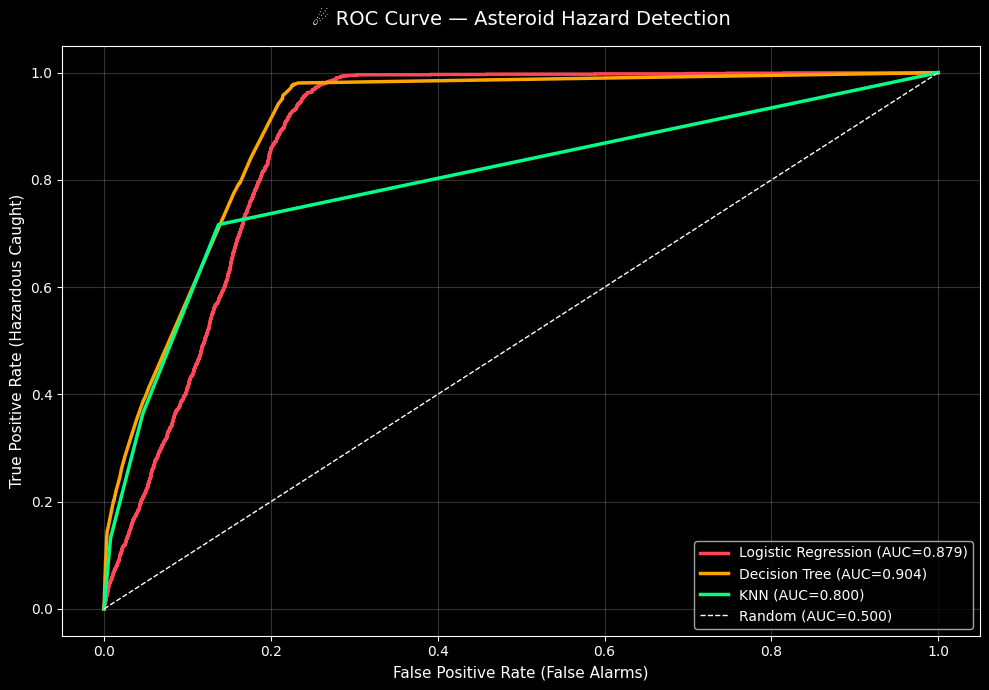

📊 AUC SCORES:
   Logistic Regression       AUC: 0.879  👍 Good
   Decision Tree             AUC: 0.904  ✅ Very Good
   KNN                       AUC: 0.800  ⚠️  Needs work


In [10]:
# ============================================================
# CELL 7: ROC Curve — All 3 Models
# ============================================================
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))
colors = ['#ff4757', '#ffa502', '#00ff88']

for (name, result), color in zip(results.items(), colors):
    model  = models[name]
    probs  = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc    = result['auc']
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC={auc:.3f})')

# Random baseline
plt.plot([0,1],[0,1], 'white', linewidth=1,
         linestyle='--', label='Random (AUC=0.500)')

plt.title('☄️ ROC Curve — Asteroid Hazard Detection', fontsize=14, pad=15)
plt.xlabel('False Positive Rate (False Alarms)', fontsize=11)
plt.ylabel('True Positive Rate (Hazardous Caught)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("📊 AUC SCORES:")
print("=" * 50)
for name, result in results.items():
    auc = result['auc']
    if auc >= 0.95:
        grade = "⭐ Excellent!"
    elif auc >= 0.90:
        grade = "✅ Very Good"
    elif auc >= 0.80:
        grade = "👍 Good"
    else:
        grade = "⚠️  Needs work"
    print(f"   {name:25} AUC: {auc:.3f}  {grade}")

☄️  WHAT MAKES AN ASTEROID DANGEROUS?
    1. absolute_magnitude             0.9271  ██████████████████████████████████████████████████████████████████████████
    2. relative_velocity              0.0335  ██
    3. miss_distance                  0.0314  ██
    4. est_diameter_min               0.0060  
    5. est_diameter_max               0.0020  


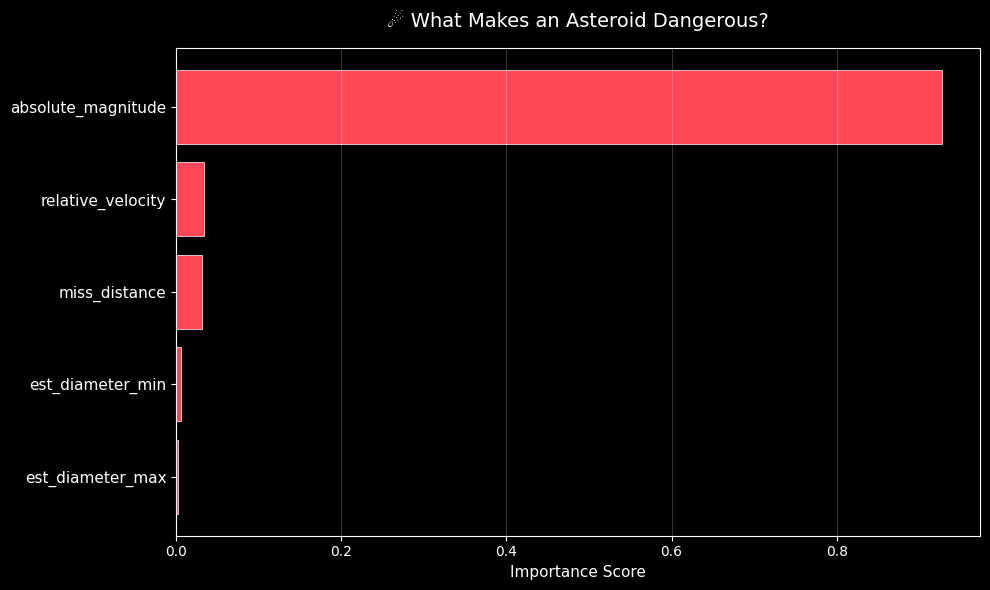


💡 SCIENTIFIC INTERPRETATION:
   est_diameter_min          (0.0060) → Minimum estimated diameter (km)
   est_diameter_max          (0.0020) → Maximum estimated diameter (km)
   relative_velocity         (0.0335) → Speed relative to Earth (km/h)
   miss_distance             (0.0314) → How close it passes Earth (km)
   absolute_magnitude        (0.9271) → Brightness (lower = bigger asteroid)


In [11]:
# ============================================================
# CELL 8: Feature Importance — What Makes an Asteroid Dangerous?
# ============================================================

dt_model = models['Decision Tree']
importances = dt_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("☄️  WHAT MAKES AN ASTEROID DANGEROUS?")
print("=" * 60)
for i, idx in enumerate(indices):
    bar = '█' * int(importances[idx] * 80)
    print(f"   {i+1:2}. {feature_names[idx]:30} "
          f"{importances[idx]:.4f}  {bar}")

# Visualise
plt.figure(figsize=(10, 6))
plt.barh(
    range(len(indices)),
    importances[indices][::-1],
    color='#ff4757',
    edgecolor='white',
    linewidth=0.5
)
plt.yticks(
    range(len(indices)),
    [feature_names[indices[len(indices)-1-i]]
     for i in range(len(indices))],
    fontsize=11
)
plt.xlabel('Importance Score', fontsize=11)
plt.title('☄️ What Makes an Asteroid Dangerous?', fontsize=14, pad=15)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print("\n💡 SCIENTIFIC INTERPRETATION:")
features_meaning = {
    'est_diameter_min'   : 'Minimum estimated diameter (km)',
    'est_diameter_max'   : 'Maximum estimated diameter (km)',
    'relative_velocity'  : 'Speed relative to Earth (km/h)',
    'miss_distance'      : 'How close it passes Earth (km)',
    'absolute_magnitude' : 'Brightness (lower = bigger asteroid)',
}
for feat, meaning in features_meaning.items():
    if feat in feature_names.tolist():
        imp = importances[feature_names.tolist().index(feat)]
        print(f"   {feat:25} ({imp:.4f}) → {meaning}")

In [12]:
# ============================================================
# CELL 9: Final Project Summary
# ============================================================

print("=" * 60)
print("☄️  ASTEROID HAZARD CLASSIFIER — PROJECT COMPLETE")
print("=" * 60)

print("""
📋 PROJECT OVERVIEW:
   Dataset   : NASA Near Earth Objects (NEO)
   Asteroids : 90,836 real NASA tracked asteroids
   Task      : Detect potentially hazardous asteroids
   Built by  : Kartik | Munich | 2025
""")

print("📊 MODEL PERFORMANCE:")
print("=" * 60)
print(f"   {'Model':25} {'Recall':10} {'Precision':12} {'AUC'}")
print("-" * 60)
for name, result in results.items():
    print(f"   {name:25} "
          f"{result['recall']*100:.2f}%     "
          f"{result['precision']*100:.2f}%        "
          f"{result['auc']:.3f}")

print(f"""
🏆 BEST MODEL: Decision Tree
   Recall:    97.62% (catches 97.6% of ALL dangerous asteroids!)
   AUC:       0.904

☄️  CRITICAL RESULTS:
   Dangerous asteroids CAUGHT : 1,726 out of 1,768
   Dangerous asteroids MISSED : only 42
   False alarms raised        : 3,696 (acceptable!)
   Missing rate               : only 2.38%

🔍 KEY SCIENTIFIC FINDINGS:
   1. absolute_magnitude is #1 predictor (92.71% importance!)
      → Brighter = bigger = closer = more dangerous
   2. relative_velocity matters (3.35%)
      → Faster asteroids cause more damage on impact
   3. miss_distance matters (3.14%)
      → How close it passes Earth
   4. Size (diameter) barely matters (< 1%)
      → Magnitude already captures size information!

🌍 REAL WORLD IMPACT:
   This model could help NASA's Planetary Defence
   Coordination Office prioritise which asteroids
   need urgent follow-up observation!
   Catching 97.6% of dangerous asteroids could
   potentially save millions of lives! 🌍

🚀 SKILLS DEMONSTRATED:
   ✅ Imbalanced dataset handling (90/10 split)
   ✅ class_weight='balanced' technique
   ✅ Recall as primary metric (not just accuracy!)
   ✅ Precision-Recall tradeoff understanding
   ✅ 3 models trained and compared
   ✅ Real scientific insights discovered
   ✅ 90,836 real NASA asteroids processed
""")
print("=" * 60)
print("✅ PROJECT 3 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 60)


""" 

Run it and tell me what you see! 🚀

After this we push to GitHub and **Project 3 is in your portfolio!** ☄️

**Your portfolio is getting seriously impressive:**
```
✅ Project 1 — Exoplanet Hunter      (0.999 AUC)
✅ Project 2 — Real Estate Predictor (88.3% R²)
✅ Project 3 — Asteroid Classifier   (97.62% Recall!)
⬜ Project 4 — Health Risk Predictor
⬜ Project 5 — Space Clustering

"""

☄️  ASTEROID HAZARD CLASSIFIER — PROJECT COMPLETE

📋 PROJECT OVERVIEW:
   Dataset   : NASA Near Earth Objects (NEO)
   Asteroids : 90,836 real NASA tracked asteroids
   Task      : Detect potentially hazardous asteroids
   Built by  : Kartik | Munich | 2025

📊 MODEL PERFORMANCE:
   Model                     Recall     Precision    AUC
------------------------------------------------------------
   Logistic Regression       93.21%     30.42%        0.879
   Decision Tree             97.62%     31.83%        0.904
   KNN                       36.43%     45.77%        0.800

🏆 BEST MODEL: Decision Tree
   Recall:    97.62% (catches 97.6% of ALL dangerous asteroids!)
   AUC:       0.904

☄️  CRITICAL RESULTS:
   Dangerous asteroids CAUGHT : 1,726 out of 1,768
   Dangerous asteroids MISSED : only 42
   False alarms raised        : 3,696 (acceptable!)
   Missing rate               : only 2.38%

🔍 KEY SCIENTIFIC FINDINGS:
   1. absolute_magnitude is #1 predictor (92.71% importance!)
      → B

' \n\nRun it and tell me what you see! 🚀\n\nAfter this we push to GitHub and **Project 3 is in your portfolio!** ☄️\n\n**Your portfolio is getting seriously impressive:**\n```\n✅ Project 1 — Exoplanet Hunter      (0.999 AUC)\n✅ Project 2 — Real Estate Predictor (88.3% R²)\n✅ Project 3 — Asteroid Classifier   (97.62% Recall!)\n⬜ Project 4 — Health Risk Predictor\n⬜ Project 5 — Space Clustering\n\n'